# ML Models Results Comparison

In [8]:
#import libraries
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

pd.set_option('display.precision', 4)

## 1. Create empty dataset to save metrics differences

In [9]:
DATA_TYPES = ['Real','GM','ECDF','SDV','CTGAN']
SYNTHESIZERS = ['GM','ECDF','SDV','CTGAN']
ml_models = ['RF','KNN','DT','SVM','MLP']

## 2. Read obtained results when TRTR and TSTR

In [10]:
FILEPATHS = {'Real' : 'RESULTS/models_results_real.csv',
            'GM' : 'RESULTS/models_results_gm.csv',
            'ECDF' : 'RESULTS/models_results_ecdf.csv',
            'CTGAN' : 'RESULTS/models_results_ctgan.csv',
            'SDV' : 'RESULTS/models_results_sdv.csv'}
            # 'WGANGP' : 'RESULTS/models_results_wgangp.csv'}

In [11]:
#iterate over all datasets filepaths and read each dataset
results_all = dict()
for name, path in FILEPATHS.items() :
    results_all[name] = pd.read_csv(path, index_col='model')
results_all

{'Real':        accuracy  precision  recall      f1
 model                                     
 RF       0.8333     0.8333  0.8333  0.8333
 KNN      0.7917     0.7982  0.7917  0.7936
 DT       0.9167     0.9167  0.9167  0.9167
 SVM      0.9583     0.9609  0.9583  0.9578
 MLP      0.8750     0.8750  0.8750  0.8733,
 'GM':        accuracy  precision  recall      f1
 model                                     
 RF       0.8750     0.8750  0.8750  0.8733
 KNN      0.8750     0.8750  0.8750  0.8733
 DT       0.7917     0.7982  0.7917  0.7936
 SVM      0.9167     0.9167  0.9167  0.9167
 MLP      0.7917     0.7982  0.7917  0.7936,
 'ECDF':        accuracy  precision  recall      f1
 model                                     
 RF       0.9167     0.9265  0.9167  0.9141
 KNN      0.7500     0.7675  0.7500  0.7536
 DT       0.7917     0.7982  0.7917  0.7936
 SVM      0.8750     0.8804  0.8750  0.8761
 MLP      0.9167     0.9167  0.9167  0.9167,
 'CTGAN':        accuracy  precision  recall      f

## 3. Calculate differences of models

In [12]:
metrics_diffs_all = dict()
real_metrics = results_all['Real']
columns = ['data','accuracy_diff','precision_diff','recall_diff','f1_diff']
metrics = ['accuracy','precision','recall','f1']

for name in SYNTHESIZERS :
    syn_metrics = results_all[name]
    metrics_diffs_all[name] = pd.DataFrame(columns = columns)
    for model in ml_models :
        real_metrics_model = real_metrics.loc[model]
        syn_metrics_model = syn_metrics.loc[model]
        data = [model]
        for m in metrics :
            data.append(abs(real_metrics_model[m] - syn_metrics_model[m]))
        metrics_diffs_all[name] = pd.concat([metrics_diffs_all[name], pd.DataFrame([data], columns = columns)], ignore_index=True)
metrics_diffs_all

{'GM':   data  accuracy_diff  precision_diff  recall_diff  f1_diff
 0   RF         0.0417          0.0417       0.0417   0.0400
 1  KNN         0.0833          0.0768       0.0833   0.0797
 2   DT         0.1250          0.1185       0.1250   0.1231
 3  SVM         0.0416          0.0442       0.0416   0.0411
 4  MLP         0.0833          0.0768       0.0833   0.0797,
 'ECDF':   data  accuracy_diff  precision_diff  recall_diff  f1_diff
 0   RF         0.0834          0.0932       0.0834   0.0808
 1  KNN         0.0417          0.0307       0.0417   0.0400
 2   DT         0.1250          0.1185       0.1250   0.1231
 3  SVM         0.0833          0.0805       0.0833   0.0817
 4  MLP         0.0417          0.0417       0.0417   0.0434,
 'SDV':   data  accuracy_diff  precision_diff  recall_diff  f1_diff
 0   RF         0.0417          0.0417       0.0417   0.0400
 1  KNN         0.0834          0.0586       0.0834   0.0806
 2   DT         0.1667          0.1492       0.1667   0.1631
 

## 4. Compare absolute differences

### 4.1. Barplots for each metric

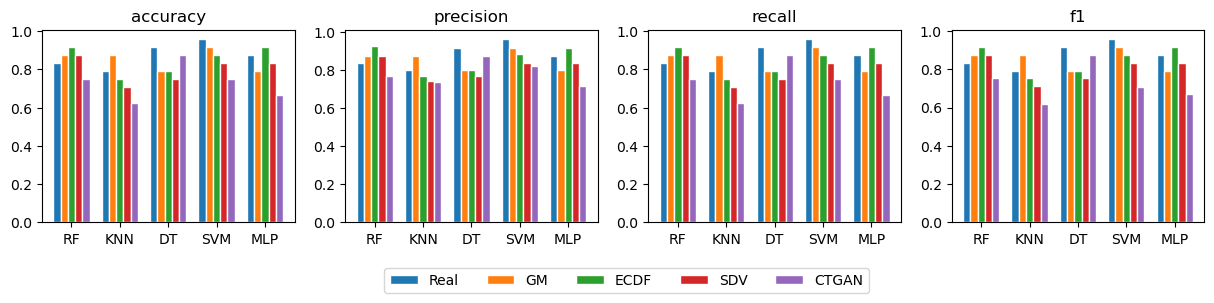

In [13]:
metrics = ['accuracy', 'precision', 'recall', 'f1']
metrics_diff = ['accuracy_diff', 'precision_diff', 'recall_diff', 'f1_diff']
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

barwidth = 0.15

fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(15, 2.5))
axs_idxs = range(4)
idx = dict(zip(metrics + metrics_diff,axs_idxs))

for i in range(0,len(metrics)) :
    data = dict()
    y_pos = dict()
    y_pos[0] = np.arange(len(ml_models))
    ax = axs[idx[metrics[i]]]
    
    for k in range(0,len(DATA_TYPES)) :
        generator_data = results_all[DATA_TYPES[k]] 
        data[k] = [0, 0, 0, 0, 0]
        
        for p in range(0,len(ml_models)) :
            data[k][p] = generator_data[metrics[i]].iloc[p]
            
        ax.bar(y_pos[k], data[k], color=colors[k], width=barwidth, edgecolor='white', label=DATA_TYPES[k])
        y_pos[k+1] = [x + barwidth for x in y_pos[k]]
        
    ax.set_xticks([r + barwidth*2 for r in range(len(ml_models))])
    ax.set_xticklabels([])
    ax.set_xticklabels(ml_models, fontsize=10)
    ax.set_title(metrics[i], fontsize=12)
    
ax.legend(DATA_TYPES, ncol=5, bbox_to_anchor=(-0.3, -0.2))
fig.tight_layout()
#fig.suptitle('Models performance comparisson Boxplots (TRTR and TSTR) \n Dataset F - Indian Liver Patient', fontsize=18)
fig.savefig('RESULTS/MODELS_METRICS_BARPLOTS.svg', bbox_inches='tight')

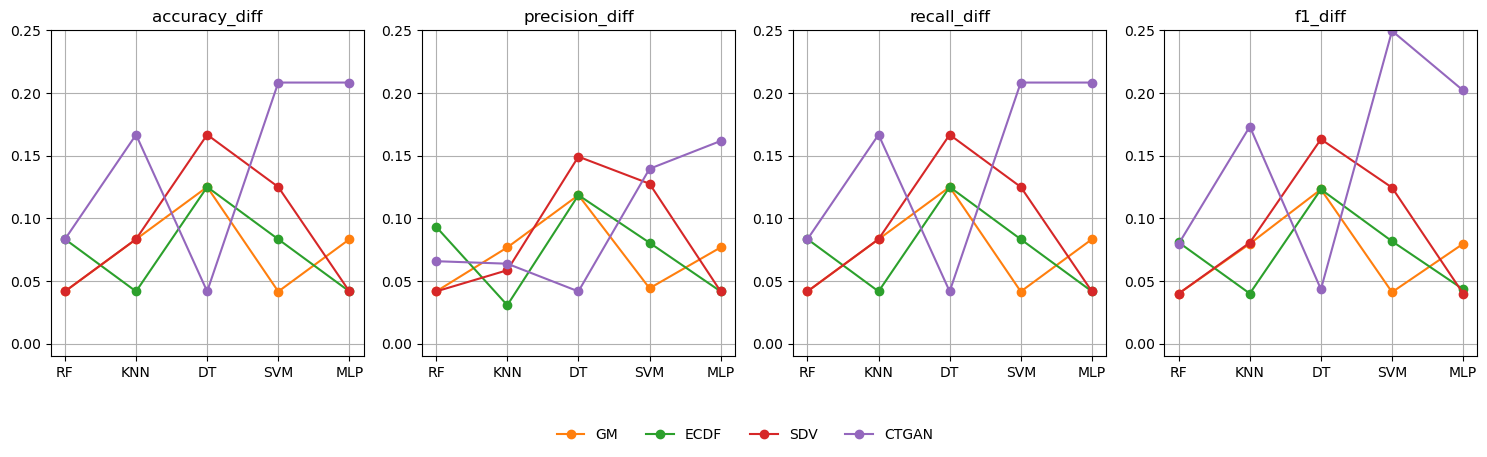

In [14]:
metrics = ['accuracy_diff', 'precision_diff', 'recall_diff', 'f1_diff']
colors = ['tab:orange', 'tab:green', 'tab:red', 'tab:purple']

fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(15, 4))
axs_idxs = range(4)
idx = dict(zip(metrics, axs_idxs))

for i in range(len(metrics)):
    data = dict()
    ax = axs[idx[metrics[i]]]
    
    for k in range(len(SYNTHESIZERS)):
        generator_data = metrics_diffs_all[SYNTHESIZERS[k]] 
        data[k] = [0, 0, 0, 0, 0]
        
        for p in range(len(ml_models)):
            data[k][p] = generator_data[metrics[i]].iloc[p]
            
        ax.plot(data[k], 'o-', color=colors[k], label=SYNTHESIZERS[k])
        
    ax.set_xticks(np.arange(len(ml_models)))
    ax.set_xticklabels(ml_models, fontsize=10)
    ax.set_title(metrics[i], fontsize=12)
    ax.set_ylim(bottom=-0.01, top=0.25)
    ax.grid()

# 在整个 figure 底部中央添加图例
fig.legend(SYNTHESIZERS, ncol=len(SYNTHESIZERS), 
           bbox_to_anchor=(0.5, -0.05), loc='upper center', 
           frameon=False)

fig.tight_layout()
fig.savefig('RESULTS/MODELS_METRICS_DIFFERENCES.svg', bbox_inches='tight')